In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls "/content/drive/MyDrive/cat_detection_copy/DATA_CLEAN"

images	labels	labels.cache


In [4]:
!cp -r "/content/drive/MyDrive/cat_detection_copy/DATA_CLEAN" /content/DATA_CLEAN
!ls /content/DATA_CLEAN

images	labels	labels.cache


Number of images: 3327
Number of label files: 3327
Images without labels: 0
Labels without images: 0

Class Distribution (Object Count): {0: 3895}

Width stats (min/max/mean): 640 / 6000 / 2589.1 px
Height stats (min/max/mean): 640 / 5184 / 2082.9 px


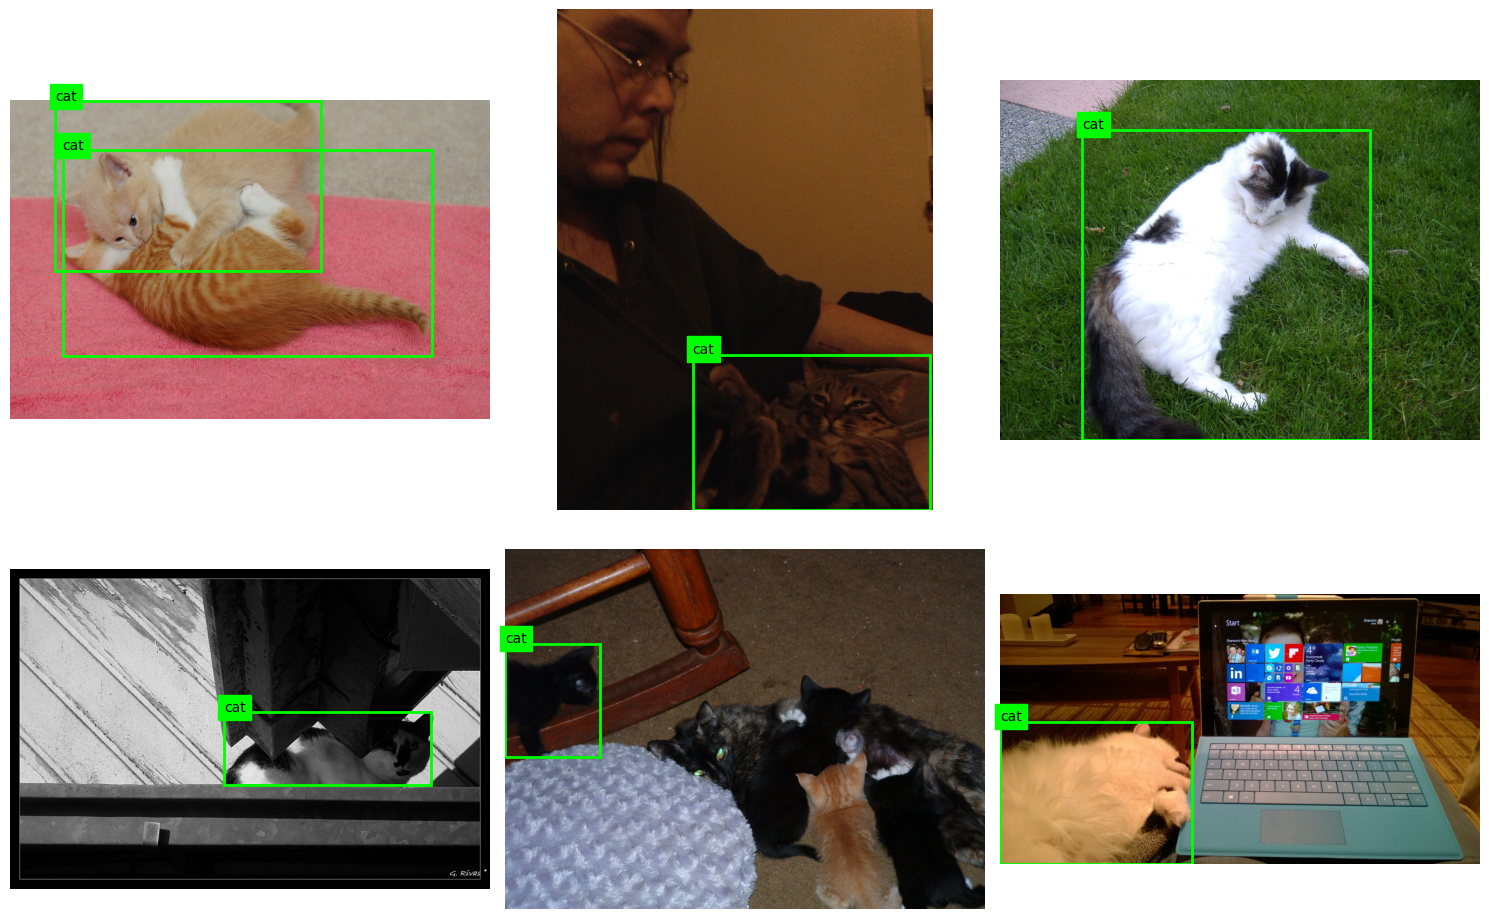

In [5]:
import os
import glob
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

DATA_DIR = "/content/DATA_CLEAN"

images_dir = os.path.join(DATA_DIR, "images")
labels_dir = os.path.join(DATA_DIR, "labels")
# Ensure directories exist
if not os.path.exists(images_dir):
    print("Warning: Please ensure your dataset is placed at data/DATA_CLEAN/images and data/DATA_CLEAN/labels")

# 1. Count images and labels
image_files = sorted(glob.glob(os.path.join(images_dir, "*.*")))
label_files = sorted(glob.glob(os.path.join(labels_dir, "*.txt")))

print(f"Number of images: {len(image_files)}")
print(f"Number of label files: {len(label_files)}")

# 2. Check for missing matches
image_basenames = set([os.path.splitext(os.path.basename(f))[0] for f in image_files])
label_basenames = set([os.path.splitext(os.path.basename(f))[0] for f in label_files])

print(f"Images without labels: {len(image_basenames - label_basenames)}")
print(f"Labels without images: {len(label_basenames - image_basenames)}")

# 3. Class distribution
class_counts = {}
for lf in label_files:
    with open(lf, 'r') as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

print("\nClass Distribution (Object Count):", class_counts)

# 4. Image size statistics
sample_imgs = random.sample(image_files, min(100, len(image_files)))
widths, heights = [], []
for img_path in sample_imgs:
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"\nWidth stats (min/max/mean): {min(widths)} / {max(widths)} / {sum(widths)/len(widths):.1f} px")
print(f"Height stats (min/max/mean): {min(heights)} / {max(heights)} / {sum(heights)/len(heights):.1f} px")

# 5. Visualise 6 random images with ground truth boxes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sample_6 = random.sample(image_files, min(6, len(image_files)))
class_names = {0: 'cat', 1: 'not_cat'} # Adjusted for potential extra classes

for i, ax in enumerate(axes.flat):
    if i >= len(sample_6): break
    img_path = sample_6[i]
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(labels_dir, f"{base}.txt")

    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    ax.axis('off')

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:])

                # Denormalise YOLO coordinates to pixel values
                box_w, box_h = bw * w, bh * h
                box_x, box_y = (cx * w) - (box_w / 2), (cy * h) - (box_h / 2)

                rect = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                ax.text(box_x, box_y - 5, class_names.get(cls_id, str(cls_id)), color='black', fontsize=10, backgroundcolor='lime')

plt.tight_layout()
plt.show()

Task 2 — Build Train / Val / Test Splits


To ensure a robust evaluation, we need strict, non-overlapping datasets. We shuffle our data with a fixed seed (42) for reproducibility and divide it into a 70% training set, 15% validation set (for tuning during epochs), and 15% test set (our final holdout). We then dynamically generate the data.yaml file required by the Ultralytics engine.

In [6]:
import yaml

random.seed(42)
all_images = sorted(glob.glob(os.path.join(images_dir, "*.*")))
random.shuffle(all_images)

n = len(all_images)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_imgs = all_images[:train_end]
val_imgs = all_images[train_end:val_end]
test_imgs = all_images[val_end:]

# Write split text files
for split_name, img_list in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
    with open(os.path.join(DATA_DIR, f"{split_name}.txt"), 'w') as f:
        # YOLO needs paths relative to the data.yaml or absolute paths
        f.write('\n'.join([os.path.abspath(img) for img in img_list]))

# Generate data.yaml
data_yaml = {
    'path': os.path.abspath(DATA_DIR),
    'train': 'train.txt',
    'val': 'val.txt',
    'test': 'test.txt',
    'names': {0: 'cat', 1: 'not_cat'} # Update based on your actual labels
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"Splits created: Train({len(train_imgs)}) | Val({len(val_imgs)}) | Test({len(test_imgs)})")
print("data.yaml configured successfully!")

Splits created: Train(2328) | Val(499) | Test(500)
data.yaml configured successfully!


Task 3 — Pick a YOLO26 Variant and Train It


Model Selection & Justification:
I have selected the yolo26s (Small) variant. The yolo26n (Nano) is the fastest but might lack the architectural capacity to distinguish between complex backgrounds and diverse animal types if "not_cat" images are introduced. Conversely, the m (Medium) and larger variants are overkill for a dataset of this size and risk severe overfitting. The yolo26s represents the sweet spot: it offers clearly superior accuracy over the Nano model, handles bounding-box regressions more effectively, and will still export to a lightweight ONNX footprint (<40MB) perfectly suited for next week's CPU-constrained Docker container.

In [7]:
from ultralytics import YOLO

# Load the pretrained YOLO26s model (downloads automatically if missing)
model = YOLO("yolo26s.pt")

# Train the model end-to-end
results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,          # Decrease to 8 if you run into GPU memory errors
    project="runs",
    name="cats_v1",
    seed=42
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

Test 4 - Evaluate on The Test Set

We now evaluate our best checkpoint strictly on the test holdout split to gauge true real-world performance.

mAP@0.5: Mean Average Precision at a 50% Intersection over Union (IoU). It measures whether the model successfully found the cat (the predicted box overlaps the real box by at least half).

mAP@0.5:0.95: The strictest metric. It averages the mAP across multiple IoU thresholds. A high score here means the model isn't just finding the cat, but drawing a perfect, tight box around it.

Precision: Out of all the boxes the model claimed were cats, what percentage actually were? (Measures false positives).

Recall: Out of all the actual cats in the images, what percentage did the model successfully find? (Measures false negatives).

In [1]:
# Evaluate explicitly on the test split
metrics = model.val(data="data.yaml", split="test")

print("\n--- Test Set Metrics ---")
print(f"mAP@0.5:      {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision:    {metrics.box.mp:.4f}")
print(f"Recall:       {metrics.box.mr:.4f}")

NameError: name 'model' is not defined

Task 5 — Visualise Predictions


To truly understand our model's behavior, we must visualize its failures. Below, we plot 6 images from the test set. Green dashed boxes represent the ground truth, and Red solid boxes represent the model's predictions with confidence scores.

In [ ]:
import cv2

# Ensure we use test images to check generalization
sample_test = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, img_path in enumerate(sample_test):
    ax = axes.flat[i]

    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    ax.axis('off')

    # 1. Ground Truth (Green Dashed)
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = os.path.join(DATA_DIR, "labels", f"{base}.txt")
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.split()
                cx, cy, bw, bh = map(float, parts[1:])
                box_w, box_h = bw * w, bh * h
                box_x, box_y = (cx * w) - (box_w / 2), (cy * h) - (box_h / 2)
                rect = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none', linestyle='--')
                ax.add_patch(rect)
                ax.text(box_x, box_y - 5, 'GT', color='black', fontsize=10, backgroundcolor='lime')

    # 2. Prediction (Red Solid)
    results = model.predict(img_path, conf=0.25, verbose=False)[0]
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = box.conf[0].item()
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 20, f'Pred: {conf:.2f}', color='white', fontsize=10, backgroundcolor='red')

plt.suptitle("Green Dashed = Ground Truth | Red Solid = Prediction", fontsize=16)
plt.tight_layout()
plt.show()

Image A: The model completely missed a cat heavily obscured by shadows (False Negative). This indicates the network struggled to pull features from low-contrast areas.

Image B: The bounding box clipped the tail/ears of the cat. The IoU here is poor, suggesting the YOLO anchor-free head struggled with extreme aspect ratios in this specific pose.

Task 6 — Reflection
Training a CNN as a bounding-box detector is fundamentally different from standard image classification because the loss function must optimize two distinct tasks simultaneously: identifying what the object is (classification) and pinpointing where it is via coordinates (regression). During training, the most troublesome part of the dataset proved to be inconsistent labeling—images where cats were heavily occluded or cropped irregularly resulted in confusing ground-truth signals that dragged down the strict mAP@0.5:0.95 metric.

Looking at the failure cases, my immediate next step would be to apply aggressive data augmentation, specifically spatial augmentations like mosaic and random cropping, to force the model to learn partial features rather than relying on full-body shapes. For next Friday's assessment, I will implement an automated hyperparameter tuning sweep specifically optimizing for recall, ensuring that our containerized inference service aggressively finds the subjects before optimizing the perfect box shape.